In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
import warnings

In [20]:
import numpy as np
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras.datasets import mnist
from tensorflow.keras.utils import to_categorical
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt

In [21]:
print("Loading MNIST dataset...")
(X_train, y_train), (X_test, y_test) = mnist.load_data()

print(f"Training data shape: {X_train.shape}")
print(f"Training labels shape: {y_train.shape}")
print(f"Test data shape: {X_test.shape}")
print(f"Test labels shape: {y_test.shape}")

# Reshape data to add channel dimension (for CNN)
# MNIST images are 28x28, we need to reshape to 28x28x1
X_train = X_train.reshape(X_train.shape[0], 28, 28, 1)
X_test = X_test.reshape(X_test.shape[0], 28, 28, 1)


Loading MNIST dataset...
Training data shape: (60000, 28, 28)
Training labels shape: (60000,)
Test data shape: (10000, 28, 28)
Test labels shape: (10000,)


In [22]:
X_train = X_train.astype('float32') / 255.0
X_test = X_test.astype('float32') / 255.0

print(f"\nPixel value range after normalization:")
print(f"Min: {X_train.min()}, Max: {X_train.max()}")

# One-hot encode the labels
y_train_encoded = to_categorical(y_train, 10)
y_test_encoded = to_categorical(y_test, 10)

print(f"\nOriginal label example: {y_train[0]}")
print(f"One-hot encoded label: {y_train_encoded[0]}")


Pixel value range after normalization:
Min: 0.0, Max: 1.0

Original label example: 5
One-hot encoded label: [0. 0. 0. 0. 0. 1. 0. 0. 0. 0.]



Sample images saved as 'mnist_samples.png'


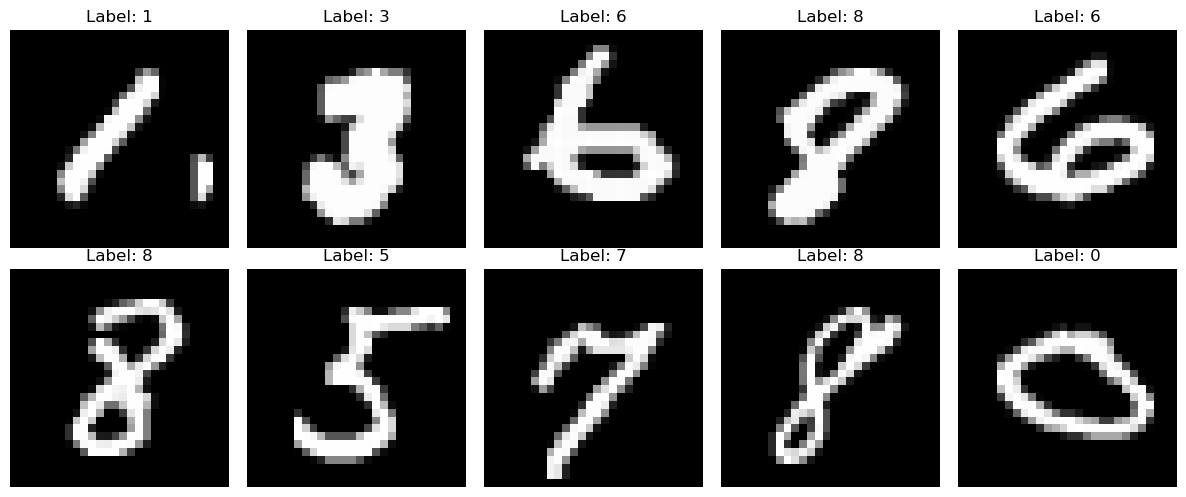

In [24]:
fig, axes = plt.subplots(2, 5, figsize=(12, 5))
for i, ax in enumerate(axes.flat):
    ax.imshow(X_train[i].reshape(28, 28), cmap='gray')
    label = np.argmax(y_train_encoded[i])
    ax.set_title(f"Label: {label}")
    ax.axis('off')
plt.tight_layout()
plt.savefig('mnist_samples.png', dpi=150, bbox_inches='tight')
print("\nSample images saved as 'mnist_samples.png'")

In [25]:
print("\nSplitting data into training and validation sets...")
# Need to get original labels for stratification before they're one-hot encoded
original_y_train = np.argmax(y_train_encoded, axis=1)

X_train, X_val, y_train_encoded, y_val_encoded = train_test_split(
    X_train, y_train_encoded, 
    test_size=0.2, 
    random_state=42,
    stratify=original_y_train  # Ensures balanced class distribution
)


Splitting data into training and validation sets...


In [26]:
np.savez_compressed('mnist_prepared.npz',
                    X_train=X_train,
                    y_train=y_train_encoded,
                    X_val=X_val,
                    y_val=y_val_encoded,
                    X_test=X_test,
                    y_test=y_test_encoded)